# Import dataset and flatter multi-level columns

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

FILE = "../data/raw/AAPL_1h.csv"
df = pd.read_csv(FILE, header=[0,1], index_col=0)

# Convert index to datetime
df.index = pd.to_datetime(df.index)

# Flatten multi-level columns
df.columns = df.columns.get_level_values(0)
df = df.sort_index()

# Target variable (next close)
df["target"] = df["Close"].shift(-1)

print(df.shape)
df.tail()

(419, 7)


Datetime,Adj Close,Close,High,Low,Open,Volume,target
2026-04-29 15:30:00+00:00,269.825012,269.825012,270.146606,268.200012,268.824493,2865276,270.200012
2026-04-29 16:30:00+00:00,270.200012,270.200012,271.040009,269.750000,269.829987,2163618,269.739990
2026-04-29 17:30:00+00:00,269.739990,269.739990,270.589996,269.640015,270.209991,1643753,270.279999
2026-04-29 18:30:00+00:00,270.279999,270.279999,270.445007,269.369995,269.734985,1887172,270.190002
2026-04-29 19:30:00+00:00,270.190002,270.190002,270.359985,269.609985,270.269989,3057478,NaN


In [3]:
df[["Close", "target"]].head()


Datetime,Close,target
2026-02-03 15:30:00+00:00,268.894989,268.899994
2026-02-03 16:30:00+00:00,268.899994,269.339996
2026-02-03 17:30:00+00:00,269.339996,271.480011
2026-02-03 18:30:00+00:00,271.480011,269.209991
2026-02-03 19:30:00+00:00,269.209991,269.459991


# Check for mising values 

In [4]:
missing_values = df.isnull().sum()
print(missing_values)

Datetime
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
target       1
dtype: int64


# Visualize missing values using Bar Plot & Heat maps

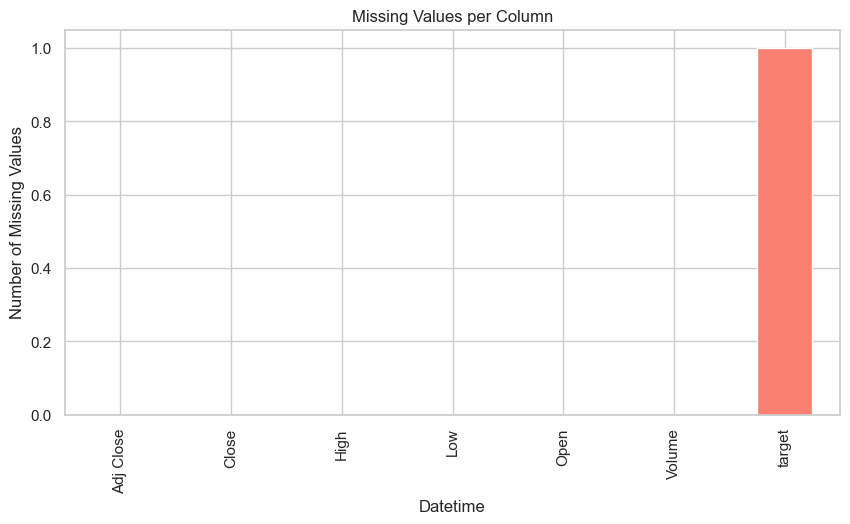

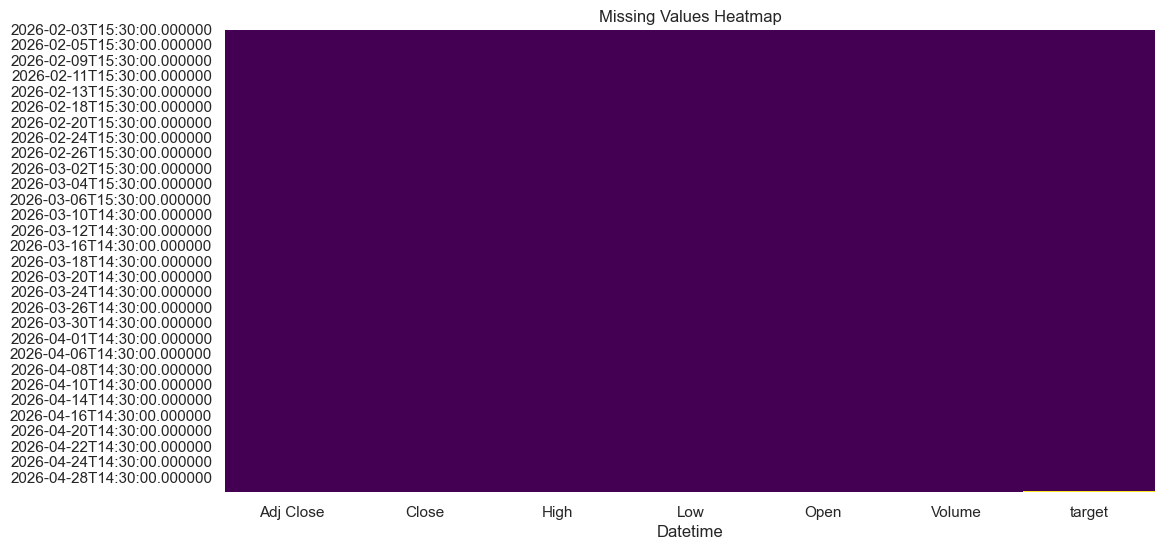

In [5]:
sns.set(style="whitegrid")


# Bar plot of missing values
plt.figure(figsize=(10,5))
missing_values.plot(kind='bar', color='salmon')
plt.title("Missing Values per Column")
plt.ylabel("Number of Missing Values")
plt.show()

# Heatmap of missing data
plt.figure(figsize=(12,6))
sns.heatmap(df.isna(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

# Check for outliers using Turkey's methode

In [6]:
cols = ["Adj Close", "Close", "High", "Low", "Open", "Volume", "target"]


df_check = df[cols].apply(pd.to_numeric, errors='coerce')

results = []

for col in cols:
    Q1 = df_check[col].quantile(0.25)
    Q3 = df_check[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_check[
        (df_check[col] < lower_bound) |
        (df_check[col] > upper_bound)
    ]

    results.append({
        "Column": col,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": len(outliers),
        "Outlier %": round(len(outliers) / len(df_check) * 100, 2)
    })

# Create clean summary DataFrame
outlier_summary_df = pd.DataFrame(results)

outlier_summary_df

,Column,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,Adj Close,2.328403e+02,2.923158e+02,0,0.00
1,Close,2.328403e+02,2.923158e+02,0,0.00
2,High,2.333525e+02,2.932125e+02,0,0.00
3,Low,2.314740e+02,2.920766e+02,0,0.00
4,Open,2.329763e+02,2.920862e+02,0,0.00
5,Volume,-1.175448e+06,8.400864e+06,28,6.68
6,target,2.327991e+02,2.923825e+02,0,0.00


# Visualize features using boxplots 

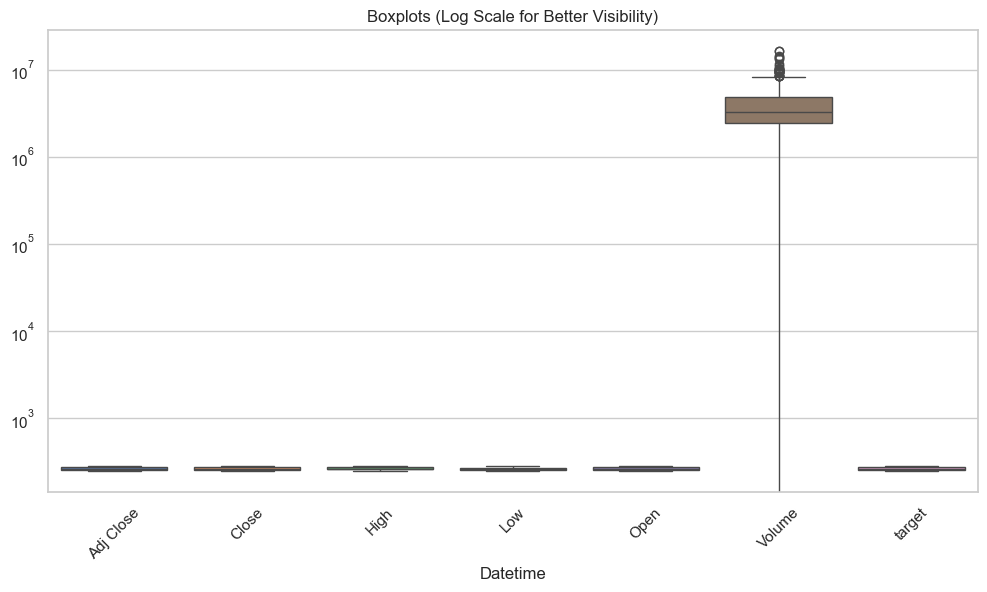

In [7]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df_check, showfliers=True)
plt.yscale("log")  # Helps with Volume scale
plt.title("Boxplots (Log Scale for Better Visibility)")
plt.xticks(rotation=45)
plt.show()

# Create new relevant features

In [8]:
# Simple Returns
df["return_1h"] = df["Close"].pct_change()

# Lag features
df["close_lag1"] = df["Close"].shift(1)
df["close_lag2"] = df["Close"].shift(2)
df["close_lag3"] = df["Close"].shift(3)

# Log Returns
df["log_return_close"] = np.log(df["Close"] / df["Close"].shift(1))
df["log_return_open"] = np.log(df["Open"] / df["Open"].shift(1))

df[["Close", "return_1h", "log_return_close"]].head()

Datetime,Close,return_1h,log_return_close
2026-02-03 15:30:00+00:00,268.894989,NaN,NaN
2026-02-03 16:30:00+00:00,268.899994,0.000019,0.000019
2026-02-03 17:30:00+00:00,269.339996,0.001636,0.001635
2026-02-03 18:30:00+00:00,271.480011,0.007945,0.007914
2026-02-03 19:30:00+00:00,269.209991,-0.008362,-0.008397


In [9]:
# Candle Shape
df["hl_range"] = (df["High"] - df["Low"]) / df["Close"]
df["oc_change"] = (df["Close"] - df["Open"]) / df["Open"]

# Rolling statistics
df["ma_5"] = df["Close"].rolling(5).mean()
df["std_5"] = df["Close"].rolling(5).std()
df["var_5"] = df["Close"].rolling(5).var()

# Bollinger Bands
k = 2
df["bb_upper"] = df["ma_5"] + k * df["std_5"]
df["bb_lower"] = df["ma_5"] - k * df["std_5"]
df["bb_width"] = df["bb_upper"] - df["bb_lower"]

df[["ma_5", "std_5", "bb_upper", "bb_lower", "bb_width"]].tail()

Datetime,ma_5,std_5,bb_upper,bb_lower,bb_width
2026-04-29 15:30:00+00:00,269.810004,0.738916,271.287835,268.332172,2.955663
2026-04-29 16:30:00+00:00,269.805005,0.735483,271.275971,268.334039,2.941932
2026-04-29 17:30:00+00:00,269.601001,0.511822,270.624644,268.577358,2.047286
2026-04-29 18:30:00+00:00,269.777002,0.573061,270.923125,268.630879,2.292246
2026-04-29 19:30:00+00:00,270.047003,0.245807,270.538617,269.555389,0.983228


In [10]:
# Momentum (difference over n periods)
n = 5
df["momentum"] = df["Close"] - df["Close"].shift(n)

# Rolling matraining_ds and min
df["rolling_max_5"] = df["Close"].rolling(n).max()
df["rolling_min_5"] = df["Close"].rolling(n).min()

# RSI (Relative Strength Index)
delta = df["Close"].diff()
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)
roll_up = gain.rolling(14).mean()
roll_down = loss.rolling(14).mean()
rs = roll_up / roll_down
df["RSI_14"] = 100 - (100 / (1 + rs))

df[["momentum", "rolling_max_5", "rolling_min_5", "RSI_14"]].tail()

Datetime,momentum,rolling_max_5,rolling_min_5,RSI_14
2026-04-29 15:30:00+00:00,-0.674988,270.760010,268.839996,64.201787
2026-04-29 16:30:00+00:00,-0.024994,270.760010,268.839996,63.705371
2026-04-29 17:30:00+00:00,-1.020020,270.200012,268.839996,63.861977
2026-04-29 18:30:00+00:00,0.880005,270.279999,268.839996,63.076672
2026-04-29 19:30:00+00:00,1.350006,270.279999,269.739990,60.886680


In [11]:
# SMA and EMA
df["SMA_10"] = df["Close"].rolling(10).mean()
df["EMA_10"] = df["Close"].ewm(span=10, adjust=False).mean()

# Trend Slope (linear regression over window)
from scipy.stats import linregress

def slope(series):
    if len(series) < len(series.index):
        return np.nan
    x = np.arange(len(series))
    y = series.values
    return linregress(x, y).slope

df["slope_10"] = df["Close"].rolling(10).apply(slope, raw=False)

df[["SMA_10", "EMA_10", "slope_10"]].tail()

#hourly TR and ATR
df["prev_close"] = df["Close"].shift(1)

high_low = df["High"] - df["Low"]
high_pc = (df["High"] - df["prev_close"]).abs()
low_pc = (df["Low"] - df["prev_close"]).abs()


# Display dataset with all new features

In [12]:
df.tail()

Datetime,Adj Close,Close,High,Low,Open,Volume,target,return_1h,close_lag1,close_lag2,...,bb_lower,bb_width,momentum,rolling_max_5,rolling_min_5,RSI_14,SMA_10,EMA_10,slope_10,prev_close
2026-04-29 15:30:00+00:00,269.825012,269.825012,270.146606,268.200012,268.824493,2865276,270.200012,0.003664,268.839996,269.399994,...,268.332172,2.955663,-0.674988,270.760010,268.839996,64.201787,270.054092,269.609410,-0.131358,268.839996
2026-04-29 16:30:00+00:00,270.200012,270.200012,271.040009,269.750000,269.829987,2163618,269.739990,0.001390,269.825012,268.839996,...,268.334039,2.941932,-0.024994,270.760010,268.839996,63.705371,269.946103,269.716792,-0.041678,269.825012
2026-04-29 17:30:00+00:00,269.739990,269.739990,270.589996,269.640015,270.209991,1643753,270.279999,-0.001703,270.200012,269.825012,...,268.577358,2.047286,-1.020020,270.200012,268.839996,63.861977,269.887601,269.721010,-0.027660,270.200012
2026-04-29 18:30:00+00:00,270.279999,270.279999,270.445007,269.369995,269.734985,1887172,270.190002,0.002002,269.739990,270.200012,...,268.630879,2.292246,0.880005,270.279999,268.839996,63.076672,269.964001,269.822644,-0.031030,269.739990
2026-04-29 19:30:00+00:00,270.190002,270.190002,270.359985,269.609985,270.269989,3057478,NaN,-0.000333,270.279999,269.739990,...,269.555389,0.983228,1.350006,270.279999,269.739990,60.886680,269.996002,269.889437,-0.024970,270.279999


# Reassamble the dataset into daily data (downsampling) 

In [13]:
# Reassemble into daily data
daily_df = df.resample('D').agg({
    'Open': 'first',
    'High': 'max',
    'Low': 'min',
    'Close': 'last',
    'Adj Close': 'last',
    'Volume': 'sum'
}).dropna(subset=['Open'])

In [14]:
# Previous close
daily_df['Prev_Close'] = daily_df['Close'].shift(1)

# True Range components
high_low = daily_df['High'] - daily_df['Low']
high_pc = (daily_df['High'] - daily_df['Prev_Close']).abs()
low_pc = (daily_df['Low'] - daily_df['Prev_Close']).abs()

# True Range
daily_df['TR'] = pd.concat([high_low, high_pc, low_pc], axis=1).max(axis=1)

# Average True Range
daily_df['ATR_3'] = daily_df['TR'].rolling(window=3).mean()

daily_df.tail()

Datetime,Open,High,Low,Close,Adj Close,Volume,Prev_Close,TR,ATR_3
2026-04-23 00:00:00+00:00,275.045013,275.769989,271.649994,273.440002,273.440002,24747520,273.190002,4.119995,6.389994
2026-04-24 00:00:00+00:00,272.760010,273.059998,269.649994,271.059998,271.059998,27728503,273.440002,3.790009,5.143331
2026-04-27 00:00:00+00:00,266.089996,268.359985,265.070007,267.679993,267.679993,28451020,271.059998,5.989990,4.633331
2026-04-28 00:00:00+00:00,272.334991,273.220001,268.660004,270.760010,270.760010,27191458,267.679993,5.540009,5.106669
2026-04-29 00:00:00+00:00,267.549988,271.040009,267.040009,270.190002,270.190002,19708544,270.760010,4.000000,5.176666


In [15]:
#compute daily SMA
daily_df["daily_SMA_10"] = daily_df["Close"].rolling(window=10).mean()

#compute daily RSI
window = 14

delta = daily_df["Close"].diff()

gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.rolling(window).mean()
avg_loss = loss.rolling(window).mean()

rs = avg_gain / avg_loss

daily_df["daily_RSI_14"] = 100 - (100 / (1 + rs))

In [16]:
# Drop NA after all features
df_ml = df.dropna().copy()

features = [
    "Close", "return_1h", "log_return_close", "log_return_open",
    "close_lag1", "close_lag2", "close_lag3",
    "hl_range", "oc_change",
    "ma_5", "std_5", "var_5",
    "bb_width",
    "momentum", "rolling_max_5", "rolling_min_5", "RSI_14",
    "SMA_10", "EMA_10", "slope_10"
]

X = df_ml[features]
y = df_ml["target"]

print(X.shape, y.shape)

(405, 20) (405,)


In [17]:
# Create return target (The percentage change in price between now & the next hour)

df['target_return'] = df['target'] / df['Close'] - 1

#Define target columns

TARGET_COLUMNS = ['target', 'target_return']

# Remove columns that will make the model cheat

LEAKAGE_COLUMNS = TARGET_COLUMNS + ['return_1h']

# Keep only columns that actually exist (safe drop)
columns_to_drop = [col for col in LEAKAGE_COLUMNS if col in df.columns]

training_ds = df.drop(columns=columns_to_drop)
y = df[TARGET_COLUMNS]

#Drop any new NaNs
training_ds = training_ds.dropna()
y = y.loc[training_ds.index]  # align target with features

# Final checks
print("Feature shape:", training_ds.shape)
print("Target shape:", y.shape)

print("\nTarget columns:", y.columns.tolist())

# Ensure no leakage
for col in TARGET_COLUMNS:
    assert col not in training_ds.columns, f"{col} still in features"

print("\nDataset is clean")

Feature shape: (406, 27)
Target shape: (406, 2)

Target columns: ['target', 'target_return']

Dataset is clean


# Training the prediction model using LSTM

In [18]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [19]:
#normalize the training and target sets for LSTM
scaler_X = MinMaxScaler()
training_scaled = scaler_X.fit_transform(training_ds)

scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(y)

print("Features scaled shape:", training_scaled.shape)
print("Targets scaled shape:", y_scaled.shape)

Features scaled shape: (406, 27)
Targets scaled shape: (406, 2)


In [20]:
#Create Sequences for LSTM
seq_len = 10  # number of past timesteps to use

def create_sequences(X, y, seq_len):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_len):
        X_seq.append(X[i:i+seq_len])
        y_seq.append(y[i+seq_len])
    return np.array(X_seq), np.array(y_seq)

training_seq, y_seq = create_sequences(training_scaled, y_scaled, seq_len)

print("training_seq shape:", training_seq.shape)  # (samples, seq_len, num_features)
print("y_seq shape:", y_seq.shape)  # (samples, num_targets)

training_seq shape: (396, 10, 27)
y_seq shape: (396, 2)


In [21]:
#Train-Test Split using time-series split
split_idx = int(0.8 * len(training_seq))
X_train, X_test = training_seq[:split_idx], training_seq[split_idx:]
y_train, y_test = y_seq[:split_idx], y_seq[split_idx:]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (316, 10, 27)
X_test shape: (80, 10, 27)


In [22]:
#buildig the LSTM model
model = Sequential()
model.add(LSTM(32, input_shape=(seq_len, training_seq.shape[2]), return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(y_seq.shape[1]))  # output layer for multi-output regression

model.compile(optimizer='adam', loss='mse')
model.summary()

d:\testmodel\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         7,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,746 (30.26 KB)

 Trainable params: 7,746 (30.26 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
#Train the model
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0785 - val_loss: nan
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0341 - val_loss: nan
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0245 - val_loss: nan
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0223 - val_loss: nan
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0205 - val_loss: nan
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0170 - val_loss: nan
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0165 - val_loss: nan
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0146 - val_loss: nan
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0146 - val_loss: nan
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0142 - val_loss: nan
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0129 - val_loss: nan


In [24]:
#predict & compare with actual values
y_pred_scaled = model.predict(X_test)

# Inverse transform to original scale
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test)

# Quick check
print("First 5 predictions:\n", y_pred[:5])
print("First 5 actuals:\n", y_true[:5])

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
First 5 predictions:
 [[ 2.5778018e+02 -1.5063550e-04]
 [ 2.5783719e+02 -6.0057652e-04]
 [ 2.5786737e+02 -1.3146333e-03]
 [ 2.5768530e+02 -1.3709906e-03]
 [ 2.5786136e+02 -4.5971255e-04]]
First 5 actuals:
 [[ 2.58325012e+02 -1.75819837e-03]
 [ 2.58855011e+02  2.05167426e-03]
 [ 2.60679993e+02  7.05020808e-03]
 [ 2.63179993e+02  9.59030256e-03]
 [ 2.64579010e+02  5.31581949e-03]]


In [26]:
model.save("lstm_model.keras")

In [27]:
import joblib

joblib.dump(scaler_X, "scaler_X.pkl")
joblib.dump(scaler_y, "scaler_y.pkl")

['scaler_y.pkl']